# 🧪 Mô Hình Học Sâu LSTM Dự Đoán Chỉ Số Chất Lượng Nước (PyTorch)

Notebook này cung cấp toàn bộ quy trình từ đầu đến cuối để xây dựng, huấn luyện và đánh giá mô hình học sâu **LSTM (Long Short-Term Memory)** bằng **PyTorch** nhằm dự báo đồng thời 3 chỉ số chất lượng nước trong hồ nuôi trồng thủy sản:
1. **water_pH** (Độ pH)
2. **TDS** (Tổng chất rắn hòa tan)
3. **water_temp** (Nhiệt độ nước)

Dữ liệu được đọc từ tệp IoT cảm biến ao nuôi thực tế: `dataset/pond_iot_2023.csv` chứa **118.286 bản ghi**.

---

## 📦 1. Khai Báo Các Thư Viện Cần Thiết

Chúng ta sử dụng **PyTorch** cho mô hình học sâu, **Pandas** và **NumPy** để tiền xử lý chuỗi thời gian, **Matplotlib/Seaborn** để vẽ biểu đồ và **Scikit-Learn** cho việc chuẩn hóa và đo lường sai số.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cấu hình giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
print("PyTorch version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

PyTorch version: 2.12.0+cpu
GPU Available: False


## 🛠️ 2. Tiền Xử Lý Dữ Liệu & Tạo Chuỗi Dữ Liệu (Data Preprocessing & Imputation)

Mã nguồn dưới đây thực hiện:
- Tải tập dữ liệu từ CSV.
- **Resample về tần suất 1 giờ (`1h`)** dùng giá trị trung bình để đồng bộ hóa chuỗi thời gian.
- Xử lý các giờ bị trống (do cảm biến mất kết nối) bằng phương pháp **nội suy tuyến tính (Linear Interpolation)**.
- Chuẩn hóa các chỉ số về khoảng `[0, 1]` bằng `MinMaxScaler`.
- Tạo các chuỗi dữ liệu (lookback = 24 giờ) làm đầu vào để dự đoán giá trị ở giờ tiếp theo.

In [2]:
def preprocess_and_prepare_data(file_path="dataset/pond_iot_2023.csv", freq="1h", lookback=24, train_ratio=0.8):
    print("--- 📥 Đang tải và tiền xử lý dữ liệu ---")
    df = pd.read_csv(file_path)
    df['created_date'] = pd.to_datetime(df['created_date'])
    df = df.sort_values('created_date')
    df = df.drop(columns=['id']).set_index('created_date')
    
    # Resample và nội suy
    print(f"Resampling dữ liệu theo tần suất '{freq}'...")
    df_resampled = df.resample(freq).mean()
    print(f"Số lượng giá trị trống trước nội suy:\n{df_resampled.isnull().sum()}")
    
    df_resampled = df_resampled.interpolate(method='linear').bfill()
    print(f"Số lượng giá trị trống sau nội suy:\n{df_resampled.isnull().sum()}")
    print(f"Kích thước tập dữ liệu sau resampling: {df_resampled.shape}")
    
    # Chuẩn hóa dữ liệu
    features = ['water_pH', 'TDS', 'water_temp']
    data = df_resampled[features].values
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Tạo chuỗi LSTM
    X, y = [], []
    for i in range(len(scaled_data) - lookback):
        X.append(scaled_data[i : i + lookback])
        y.append(scaled_data[i + lookback])
        
    X = np.array(X)
    y = np.array(y)
    
    # Chia train/test theo thời gian
    train_size = int(len(X) * train_ratio)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")
    
    return X_train, y_train, X_test, y_test, scaler, df_resampled

## 🧠 3. Định Nghĩa Kiến Trúc Mạng LSTM Bằng PyTorch

Chúng ta xây dựng mạng thần kinh LSTM gồm:
- Một lớp LSTM 2 lớp (stacked LSTM) có 64 hidden units và cơ chế Dropout giảm thiểu Overfitting.
- Lấy trạng thái ẩn của bước cuối cùng trong chuỗi làm biểu diễn nén (context vector).
- Đưa qua lớp fully connected (Dense Layer) để đưa về 3 đầu ra dự đoán (`pH`, `TDS`, `temp` ở bước kế tiếp).

In [3]:
class WaterQualityLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=2, output_size=3, dropout=0.2):
        super(WaterQualityLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, output_size)
        )
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out_last = out[:, -1, :]
        prediction = self.fc(out_last)
        return prediction

# PyTorch Custom Dataset
class WaterQualityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 🚀 4. Thiết Kế Vòng Lặp Huấn Luyện (Training with Early Stopping)

Vòng lặp huấn luyện dưới đây sử dụng bộ tối ưu hóa **Adam** và cơ chế **Early Stopping** với `patience=15`. Nếu MSE loss trên tập kiểm thử không giảm sau 15 epochs liên tiếp, quá trình huấn luyện sẽ dừng lại để tránh overfitting.

In [4]:
def train_lstm(epochs=100, batch_size=32, lr=0.001, patience=15):
    # Tải dữ liệu và chuẩn bị bộ scaler
    X_train, y_train, X_test, y_test, scaler, df_resampled = preprocess_and_prepare_data()
    
    os.makedirs("artifacts", exist_ok=True)
    with open("artifacts/scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
        
    # Chuẩn bị DataLoaders
    train_dataset = WaterQualityDataset(X_train, y_train)
    test_dataset = WaterQualityDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Cấu hình thiết bị
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nHuấn luyện trên thiết bị: {device}")
    
    model = WaterQualityLSTM().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    # Lịch sử huấn luyện
    train_losses, test_losses = [], []
    best_loss = float('inf')
    patience_counter = 0
    best_weights = None
    
    print("\n--- Khởi chạy Huấn luyện LSTM ---")
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_train_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_train_losses.append(loss.item())
            
        model.eval()
        epoch_test_losses = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X)
                test_loss = criterion(preds, batch_y)
                epoch_test_losses.append(test_loss.item())
                
        mean_train_loss = np.mean(epoch_train_losses)
        mean_test_loss = np.mean(epoch_test_losses)
        train_losses.append(mean_train_loss)
        test_losses.append(mean_test_loss)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} | Train MSE Loss: {mean_train_loss:.6f} | Test MSE Loss: {mean_test_loss:.6f}")
            
        # Cơ chế Early stopping
        if mean_test_loss < best_loss:
            best_loss = mean_test_loss
            patience_counter = 0
            best_weights = model.state_dict().copy()
            torch.save(best_weights, "artifacts/lstm_water_quality.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping kích hoạt ở epoch {epoch}! Best Test MSE: {best_loss:.6f}")
                break
                
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print("Đã tải bộ trọng số tối ưu nhất cho mô hình.")
        
    return model, scaler, train_losses, test_losses, X_test, y_test, df_resampled

# Chạy huấn luyện và nhận kết quả
model, scaler, train_losses, test_losses, X_test, y_test, df_resampled = train_lstm()

--- 📥 Đang tải và tiền xử lý dữ liệu ---
Resampling dữ liệu theo tần suất '1h'...
Số lượng giá trị trống trước nội suy:
water_pH      837
TDS           837
water_temp    837
dtype: int64
Số lượng giá trị trống sau nội suy:
water_pH      0
TDS           0
water_temp    0
dtype: int64
Kích thước tập dữ liệu sau resampling: (1327, 3)
X_train shape: (1042, 24, 3) | y_train shape: (1042, 3)
X_test shape: (261, 24, 3) | y_test shape: (261, 3)

Huấn luyện trên thiết bị: cpu

--- Khởi chạy Huấn luyện LSTM ---
Epoch 1/100 | Train MSE Loss: 0.145251 | Test MSE Loss: 0.105700
Epoch 5/100 | Train MSE Loss: 0.023926 | Test MSE Loss: 0.036953
Epoch 10/100 | Train MSE Loss: 0.015650 | Test MSE Loss: 0.013810
Epoch 15/100 | Train MSE Loss: 0.011772 | Test MSE Loss: 0.010898
Epoch 20/100 | Train MSE Loss: 0.009532 | Test MSE Loss: 0.007844
Epoch 25/100 | Train MSE Loss: 0.008231 | Test MSE Loss: 0.006876
Epoch 30/100 | Train MSE Loss: 0.008179 | Test MSE Loss: 0.006359
Epoch 35/100 | Train MSE Loss: 0.

## 📊 5. Biểu Đồ Lịch Sử Huấn Luyện & Đánh Giá Chi Tiết Sai Số

Để trực quan hóa chất lượng mô hình, chúng ta:
1. Vẽ đường cong Loss qua các Epochs.
2. Quy đổi ngược các dự đoán và nhãn thực tế về **đơn vị vật lý gốc** (pH, ppm, °C) rồi tính toán các chỉ số sai số **RMSE, MAE, và R² Score**.
3. Vẽ biểu đồ so sánh Thực tế vs Dự báo trên 120 giờ của tập kiểm thử.

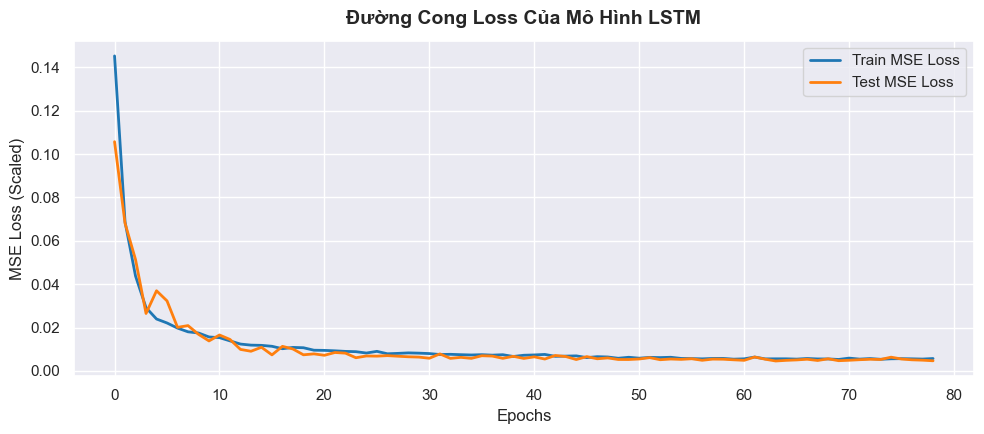

=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ ===

Chỉ số đánh giá cho: water_pH
  - RMSE: 0.1495
  - MAE:  0.0976
  - R² Score: 93.34%
------------------------------
Chỉ số đánh giá cho: TDS
  - RMSE: 20.4926 ppm
  - MAE:  13.8164 ppm
  - R² Score: 79.09%
------------------------------
Chỉ số đánh giá cho: water_temp
  - RMSE: 0.0671 °C
  - MAE:  0.0422 °C
  - R² Score: 97.07%
------------------------------


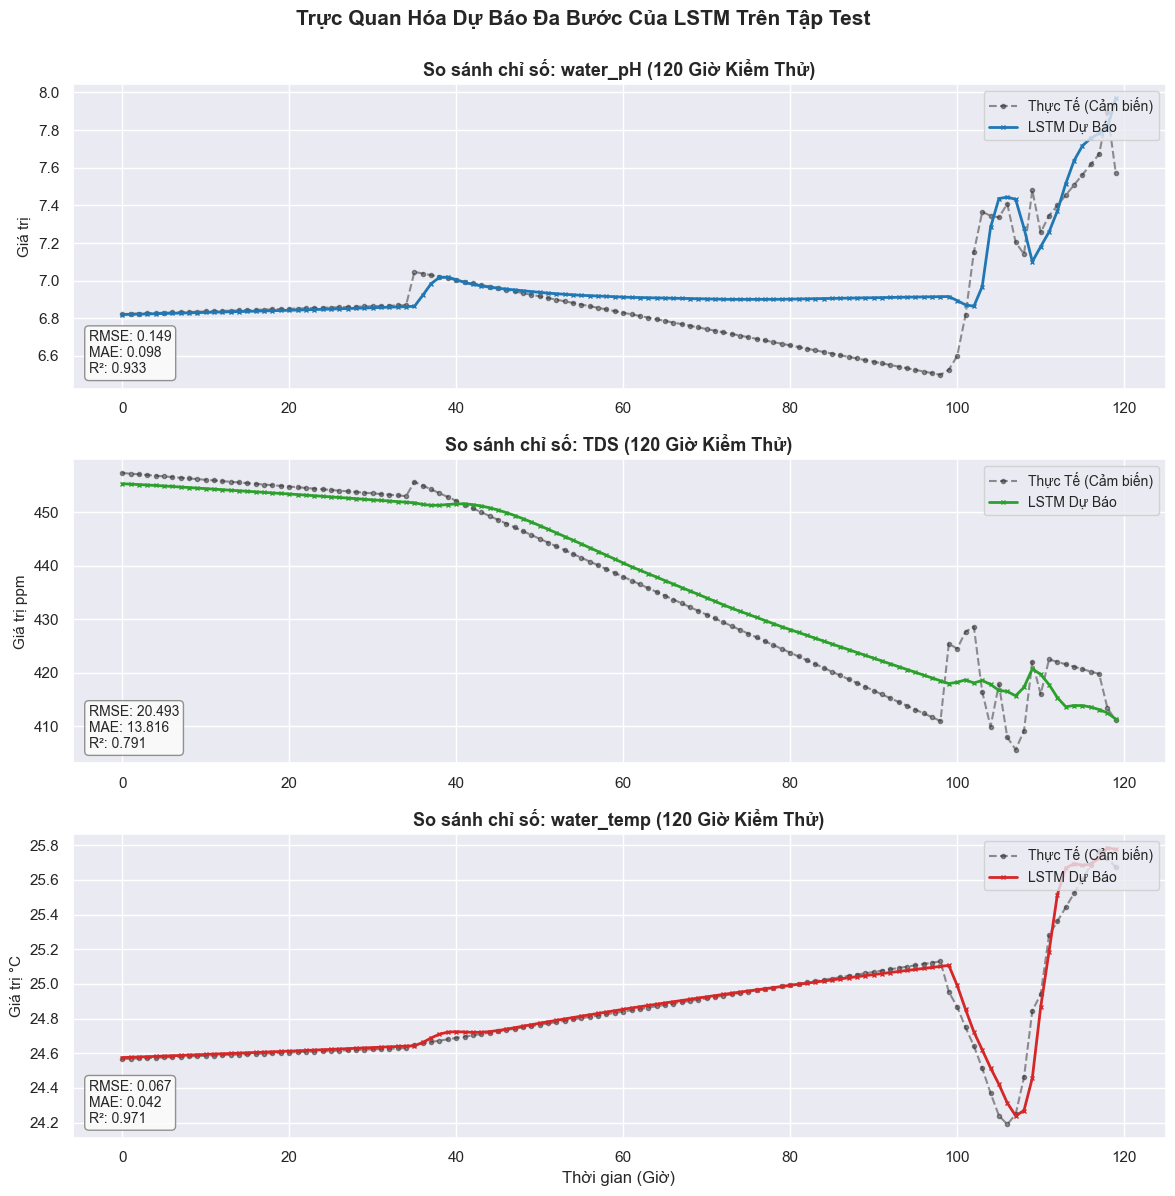

In [5]:
# 1. Biểu đồ Loss Curve
plt.figure(figsize=(10, 4.5))
plt.plot(train_losses, label='Train MSE Loss', color='#1f77b4', linewidth=2)
plt.plot(test_losses, label='Test MSE Loss', color='#ff7f0e', linewidth=2)
plt.title('Đường Cong Loss Của Mô Hình LSTM', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Loss (Scaled)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 2. Dự báo trên tập kiểm thử độc lập
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
test_dataset = WaterQualityDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_preds, all_acts = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X)
        all_preds.append(preds.cpu().numpy())
        all_acts.append(batch_y.numpy())
        
all_preds = np.concatenate(all_preds, axis=0)
all_acts = np.concatenate(all_acts, axis=0)

# Đưa ngược lại dải thang đo ban đầu
inv_preds = scaler.inverse_transform(all_preds)
inv_acts = scaler.inverse_transform(all_acts)

features = ['water_pH', 'TDS', 'water_temp']
units = ['', ' ppm', ' °C']
metrics_summary = {}

print("=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ ===\n")
for idx, feature in enumerate(features):
    rmse = np.sqrt(mean_squared_error(inv_acts[:, idx], inv_preds[:, idx]))
    mae = mean_absolute_error(inv_acts[:, idx], inv_preds[:, idx])
    r2 = r2_score(inv_acts[:, idx], inv_preds[:, idx])
    metrics_summary[feature] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    
    print(f"Chỉ số đánh giá cho: {feature}")
    print(f"  - RMSE: {rmse:.4f}{units[idx]}")
    print(f"  - MAE:  {mae:.4f}{units[idx]}")
    print(f"  - R² Score: {r2*100:.2f}%")
    print("-" * 30)

# 3. Biểu đồ so sánh Thực tế vs Dự đoán
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
colors = ['#1f77b4', '#2ca02c', '#d62728']
num_points = min(120, len(inv_acts))
plot_indices = np.arange(num_points)

for idx, feature in enumerate(features):
    ax = axes[idx]
    ax.plot(plot_indices, inv_acts[:num_points, idx], label='Thực Tế (Cảm biến)', color='#2b2b2b', alpha=0.5, linestyle='--', marker='o', markersize=3)
    ax.plot(plot_indices, inv_preds[:num_points, idx], label='LSTM Dự Báo', color=colors[idx], linewidth=2, marker='x', markersize=3)
    
    ax.set_title(f"So sánh chỉ số: {feature} (120 Giờ Kiểm Thử)", fontsize=13, fontweight='bold')
    ax.set_ylabel(f"Giá trị{units[idx]}", fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    
    # Hộp thông số góc trái
    err_text = f"RMSE: {metrics_summary[feature]['RMSE']:.3f}\nMAE: {metrics_summary[feature]['MAE']:.3f}\nR²: {metrics_summary[feature]['R2']:.3f}"
    ax.text(0.015, 0.05, err_text, transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="#fcfcfc", ec="gray", alpha=0.85))

plt.xlabel("Thời gian (Giờ)", fontsize=12)
plt.suptitle("Trực Quan Hóa Dự Báo Đa Bước Của LSTM Trên Tập Test", fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 🔮 6. Dự Báo Các Chỉ Số Chất Lượng Nước Trong Tương Lai (Future Forecasting)

Để dự toán tương lai, chúng ta trích xuất **24 giờ cuối cùng** trong tập dữ liệu lịch sử và dùng mô hình LSTM để dự báo từng giờ tiếp theo. Mô hình sẽ chạy theo cơ chế **tự hồi quy (autoregressive)**: dùng kết quả dự đoán của giờ tiếp theo làm đầu vào chuỗi để dự báo giờ kế tiếp nữa.

Thời điểm mốc lịch sử cuối cùng: 2023-03-22 17:00:00
Dữ liệu 3 giờ cuối cùng:
                     water_pH        TDS  water_temp
created_date                                        
2023-03-22 15:00:00  8.312967  389.80622   25.697069
2023-03-22 16:00:00  8.321483  384.15311   25.699785
2023-03-22 17:00:00  8.330000  378.50000   25.702500

=== KẾT QUẢ DỰ BÁO LSTM CHO 12 GIỜ TIẾP THEO ===
                     water_pH         TDS  water_temp
Thời_gian_dự_báo                                     
2023-03-22 18:00:00  8.309898  407.270660   25.734465
2023-03-22 19:00:00  8.288953  406.016235   25.764364
2023-03-22 20:00:00  8.264264  405.546692   25.796082
2023-03-22 21:00:00  8.241961  405.443756   25.825808
2023-03-22 22:00:00  8.224067  405.496033   25.853222
2023-03-22 23:00:00  8.211052  405.555634   25.879242
2023-03-23 00:00:00  8.202896  405.616180   25.904303
2023-03-23 01:00:00  8.199306  405.652283   25.928980
2023-03-23 02:00:00  8.199858  405.654633   25.953648
2023-03-23 03

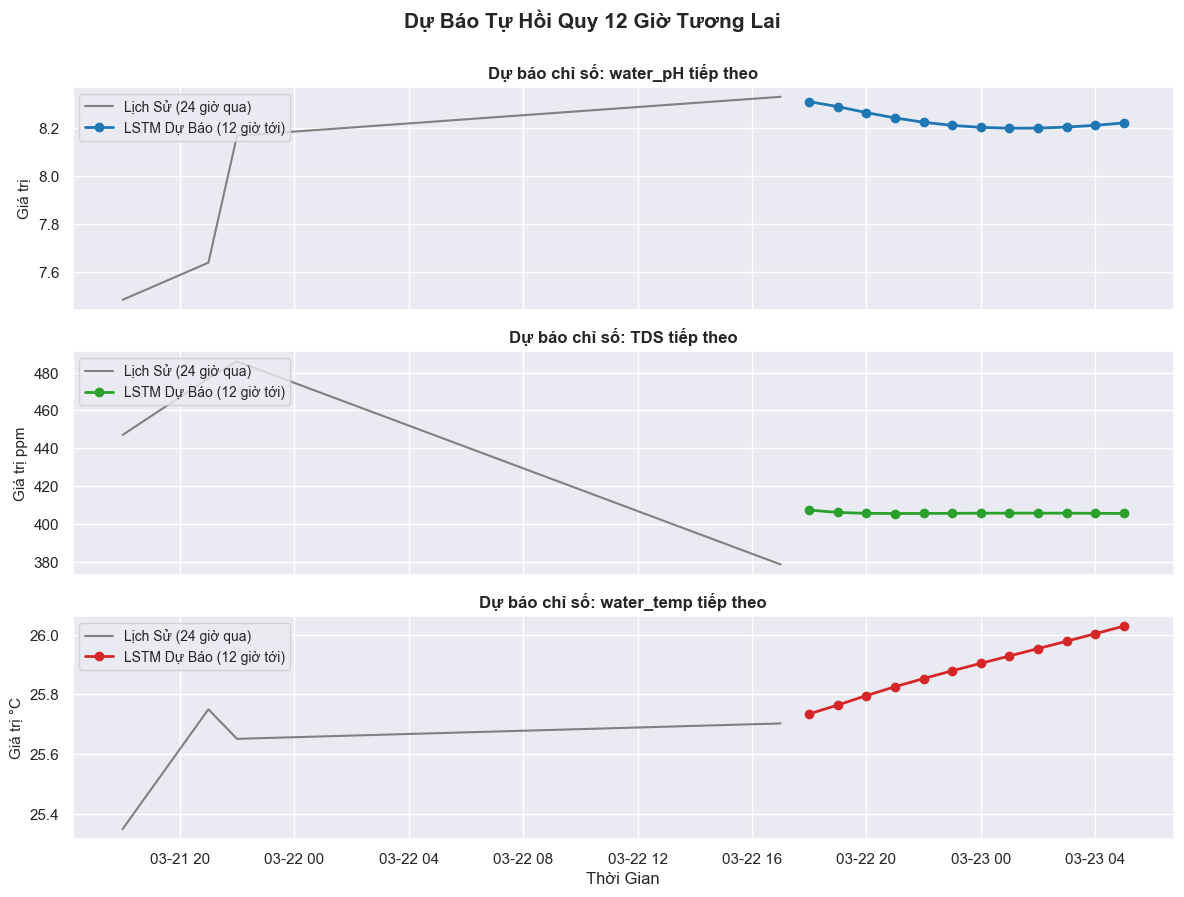

In [6]:
def forecast_future_steps(model, scaler, device, last_sequence, steps=12):
    scaled_seq = scaler.transform(last_sequence)
    current_seq = scaled_seq.copy()
    predictions = []
    
    for _ in range(steps):
        # Convert to tensor & add Batch dimension -> (1, 24, 3)
        input_tensor = torch.tensor(current_seq, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred = model(input_tensor)
            
        pred_np = pred.cpu().numpy()[0] # (3,)
        predictions.append(pred_np)
        
        # Cập nhật chuỗi (bỏ điểm đầu tiên, thêm dự báo vào cuối)
        current_seq = np.vstack([current_seq[1:], pred_np])
        
    # Quy đổi ngược thang đo gốc
    inv_predictions = scaler.inverse_transform(np.array(predictions))
    return inv_predictions

# Lấy dữ liệu 24 giờ cuối từ tập dữ liệu lịch sử đã qua tiền xử lý
lookback = 24
recent_sequence = df_resampled.tail(lookback)
last_timestamp = recent_sequence.index[-1]

print(f"Thời điểm mốc lịch sử cuối cùng: {last_timestamp}")
print("Dữ liệu 3 giờ cuối cùng:")
print(recent_sequence.tail(3))

# Dự báo 12 giờ tiếp theo trong tương lai
forecast_steps = 12
future_vals = forecast_future_steps(model, scaler, device, recent_sequence.values, steps=forecast_steps)

# Chuyển thành DataFrame có chỉ số thời gian tương ứng
forecast_times = [last_timestamp + timedelta(hours=i+1) for i in range(forecast_steps)]
forecast_df = pd.DataFrame(future_vals, columns=['water_pH', 'TDS', 'water_temp'], index=forecast_times)
forecast_df.index.name = "Thời_gian_dự_báo"

print("\n=== KẾT QUẢ DỰ BÁO LSTM CHO 12 GIỜ TIẾP THEO ===")
print(forecast_df)

# 4. Biểu đồ dự báo chu kỳ tương lai
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for idx, feature in enumerate(features):
    ax = axes[idx]
    
    # Vẽ lịch sử 24h qua
    ax.plot(recent_sequence.index, recent_sequence.values[:, idx], label='Lịch Sử (24 giờ qua)', color='gray', linestyle='-')
    # Vẽ dự báo 12h tới
    ax.plot(forecast_df.index, forecast_df.values[:, idx], label='LSTM Dự Báo (12 giờ tới)', color=colors[idx], marker='o', linewidth=2)
    
    ax.set_title(f"Dự báo chỉ số: {feature} tiếp theo", fontsize=12, fontweight='bold')
    ax.set_ylabel(f"Giá trị{units[idx]}", fontsize=11)
    ax.legend(fontsize=10, loc='upper left')
    
plt.xlabel("Thời Gian", fontsize=12)
plt.suptitle("Dự Báo Tự Hồi Quy 12 Giờ Tương Lai", fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()